### 1.When daily bolus insulin is low and hyperglycemia percentage is high, what bolus adjustment should be recommended?

****Low bolus insulin almost always increases hyperglycemia risk
Bolus insulin is the meal‑time insulin that covers carbohydrates.
When bolus volume is low:
Glucose from meals stays in the bloodstream
Post‑meal spikes rise
Hyperglycemia percentage increases
This is one of the strongest patterns in CGM data.****

In [10]:
%cd "H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files"


H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files


In [11]:
import os
os.getcwd()

'H:\\Numpy Ninja\\Python Hackathon\\Team2_ PyQueens_ Python Hackathon _MAY 2026\\Team2_ PyQueens_ Python Hackathon _MAY 2026\\Final cleaned csv files\\Final cleaned csv files'

In [12]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sn

In [13]:
df=pd.read_csv("Team2_PyQueens_Final_Cleaned_File.csv")
df.head()

,Patient_Id,Time,Glucose,Calories,Heart_Rate,Steps,Basal_Rate,Bolus_Volume_Delivered,Carb_Input
0,HUPA0001P,2018-06-13T18:40:00,332.0,6.36,82.32,34.0,0.09,0.0,0.0
1,HUPA0001P,2018-06-13T18:45:00,326.0,7.73,83.74,0.0,0.09,0.0,0.0
2,HUPA0001P,2018-06-13T18:50:00,330.0,4.75,80.53,0.0,0.09,0.0,0.0
3,HUPA0001P,2018-06-13T18:55:00,324.0,6.36,89.13,20.0,0.09,0.0,0.0
4,HUPA0001P,2018-06-13T19:00:00,306.0,5.15,92.50,0.0,0.08,0.0,0.0


In [14]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')


In [15]:
df['Patient_Id'].unique()


array(['HUPA0001P', 'HUPA0002P', 'HUPA0003P', 'HUPA0004P', 'HUPA0005P',
       'HUPA0006P', 'HUPA0007P', 'HUPA0009P', 'HUPA0010P', 'HUPA0011P',
       'HUPA0014P', 'HUPA0015P', 'HUPA0016P', 'HUPA0017P', 'HUPA0018P',
       'HUPA0019P', 'HUPA0020P', 'HUPA0021P', 'HUPA0022P', 'HUPA0023P',
       'HUPA0024P', 'HUPA0025P', 'HUPA0026P', 'HUPA0027P', 'HUPA0028P'],
      dtype=object)

In [20]:
# -----------------------------
# 1. Define hyperglycemia
# -----------------------------
HYPER_THRESHOLD = 180
df['is_hyper'] = (df['Glucose'] > HYPER_THRESHOLD).astype(int)

In [21]:
# -----------------------------
# 2. Create patient-day summary
# -----------------------------
df['date'] = pd.to_datetime(df['Time']).dt.date

daily = (
    df.groupby(['Patient_Id', 'date'])
      .agg(
          daily_bolus=('Bolus_Volume_Delivered', 'sum'),
          hyper_pct=('is_hyper', 'mean')   # % of readings above 180
      )
      .reset_index()
)
daily

,Patient_Id,date,daily_bolus,hyper_pct
0,HUPA0001P,2018-06-13,3.5,0.312500
1,HUPA0001P,2018-06-14,12.7,0.347222
2,HUPA0001P,2018-06-15,10.3,0.274306
3,HUPA0001P,2018-06-16,10.8,0.256944
4,HUPA0001P,2018-06-17,10.4,0.291667
...,...,...,...,...
1088,HUPA0028P,2022-05-14,0.0,0.152778
1089,HUPA0028P,2022-05-15,0.0,0.277778
1090,HUPA0028P,2022-05-16,28.0,0.062500
1091,HUPA0028P,2022-05-17,11.0,0.305556


In [22]:
# -----------------------------
# 3. Create bolus tertiles
# -----------------------------
daily['bolus_group'] = pd.qcut(
    daily['daily_bolus'],
    q=3,
    labels=['Low Bolus', 'Medium Bolus', 'High Bolus']
)
daily

,Patient_Id,date,daily_bolus,hyper_pct,bolus_group
0,HUPA0001P,2018-06-13,3.5,0.312500,Low Bolus
1,HUPA0001P,2018-06-14,12.7,0.347222,Medium Bolus
2,HUPA0001P,2018-06-15,10.3,0.274306,Low Bolus
3,HUPA0001P,2018-06-16,10.8,0.256944,Low Bolus
4,HUPA0001P,2018-06-17,10.4,0.291667,Low Bolus
...,...,...,...,...,...
1088,HUPA0028P,2022-05-14,0.0,0.152778,Low Bolus
1089,HUPA0028P,2022-05-15,0.0,0.277778,Low Bolus
1090,HUPA0028P,2022-05-16,28.0,0.062500,High Bolus
1091,HUPA0028P,2022-05-17,11.0,0.305556,Low Bolus


In [23]:
# -----------------------------
# 4. Prescriptive rule:
#    If LOW bolus + hyper_pct > 0.30 → recommend adjustment
# -----------------------------
daily['recommendation'] = daily.apply(
    lambda row: (
        "Increase bolus dose or review carb counting"
        if (row['bolus_group'] == 'Low Bolus' and row['hyper_pct'] > 0.30)
        else "No adjustment needed"
    ),
    axis=1
)
daily

,Patient_Id,date,daily_bolus,hyper_pct,bolus_group,recommendation
0,HUPA0001P,2018-06-13,3.5,0.312500,Low Bolus,Increase bolus dose or review carb counting
1,HUPA0001P,2018-06-14,12.7,0.347222,Medium Bolus,No adjustment needed
2,HUPA0001P,2018-06-15,10.3,0.274306,Low Bolus,No adjustment needed
3,HUPA0001P,2018-06-16,10.8,0.256944,Low Bolus,No adjustment needed
4,HUPA0001P,2018-06-17,10.4,0.291667,Low Bolus,No adjustment needed
...,...,...,...,...,...,...
1088,HUPA0028P,2022-05-14,0.0,0.152778,Low Bolus,No adjustment needed
1089,HUPA0028P,2022-05-15,0.0,0.277778,Low Bolus,No adjustment needed
1090,HUPA0028P,2022-05-16,28.0,0.062500,High Bolus,No adjustment needed
1091,HUPA0028P,2022-05-17,11.0,0.305556,Low Bolus,Increase bolus dose or review carb counting


****In the above table when the bolus group is low and the hyperglycemia percentage is high(>30%), then bolus volume (insulin) should be increased.
Further analysis below explains the amount of bolus volume to be increased.****

In [27]:
# ---------------------------------------------------------
# 2. Define glucose thresholds
# ---------------------------------------------------------
def insulin_adjustment(Glucose):
    if Glucose > 350:
        return "Severe hyperglycemia: Increase correction bolus by 30% and check ketones"
    elif Glucose > 300:
        return "Very high glucose: Increase correction bolus by 20–30%"
    elif Glucose > 250:
        return "High glucose: Increase correction bolus by 10–20%"
    elif Glucose > 180:
        return "Mild hyperglycemia: Give correction bolus"
    else:
        return "No adjustment needed"

df['insulin_recommendation'] = df['Glucose'].apply(insulin_adjustment)


In [50]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# 3. Compute max glucose per day
daily_actions = (
    df.groupby(['Patient_Id', 'Date'])
      .agg(max_glucose=('Glucose', 'max'))
      .reset_index()
)

# 4. Apply recommendation based on max_glucose
daily_actions['recommendation'] = daily_actions['max_glucose'].apply(insulin_adjustment)

daily_actions

,Patient_Id,Date,max_glucose,recommendation
0,HUPA0001P,2018-06-13,332.0,Very high glucose: Increase correction bolus by 20–30%
1,HUPA0001P,2018-06-14,271.0,High glucose: Increase correction bolus by 10–20%
2,HUPA0001P,2018-06-15,365.0,Severe hyperglycemia: Increase correction bolus by 30% and check ketones
3,HUPA0001P,2018-06-16,270.0,High glucose: Increase correction bolus by 10–20%
4,HUPA0001P,2018-06-17,298.0,High glucose: Increase correction bolus by 10–20%
...,...,...,...,...
1088,HUPA0028P,2022-05-14,208.0,Mild hyperglycemia: Give correction bolus
1089,HUPA0028P,2022-05-15,267.0,High glucose: Increase correction bolus by 10–20%
1090,HUPA0028P,2022-05-16,218.0,Mild hyperglycemia: Give correction bolus
1091,HUPA0028P,2022-05-17,256.0,High glucose: Increase correction bolus by 10–20%


****Key Insights:****

****Many patient‑days show max glucose in hyperglycemic ranges, often above 250–300 mg/dL, indicating frequent high‑risk periods.****
****Most days require some correction action, with only a small fraction falling into “no adjustment needed.”****
****Repeated high‑glucose days for the same patient suggest consistent under‑bolusing or missed corrections rather than isolated events.****
****The recommendation layer adds simple, actionable guidance (e.g., increase correction bolus 20–30%), turning raw CGM data into meaningful decision support.****

### 2. Identify sleep disturbance percentage patterns and correlation between sleep disturbance % and glucose values? What interventions should be suggested for patients with high sleep disturbance percentages? ###

****Higher sleep disturbance % leads to  higher glucose the next day. Fragmented or poor‑quality sleep increases cortisol and adrenaline, which raise fasting and daytime glucose. Sleep disturbance reduces insulin sensitivity. When sleep is broken, muscles respond less to insulin, leading to higher post‑meal spikes and more time above range.More sleep disturbance = more glucose variability.People with high disturbance % show wider swings, unpredictable spikes, and less stable overnight glucose.Disturbed sleep increases morning insulin resistance. This makes breakfast spikes especially worse on poor‑sleep nights.High sleep disturbance % is a behavioral risk marker.It signals stress, irregular routines, or poor recovery — all of which push glucose upward.****

In [26]:
df_sleep=pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")
df_sleep.head()

,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


In [29]:
df_sleep.columns = df_sleep.columns.str.replace('_', ' ').str.title().str.replace(' ', '_')
df_sleep.head()

,Patient_Id,Age,Gender,Race,Average_Sleep_Duration_(Hrs),Sleep_Quality_(1-10),%_With_Sleep_Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


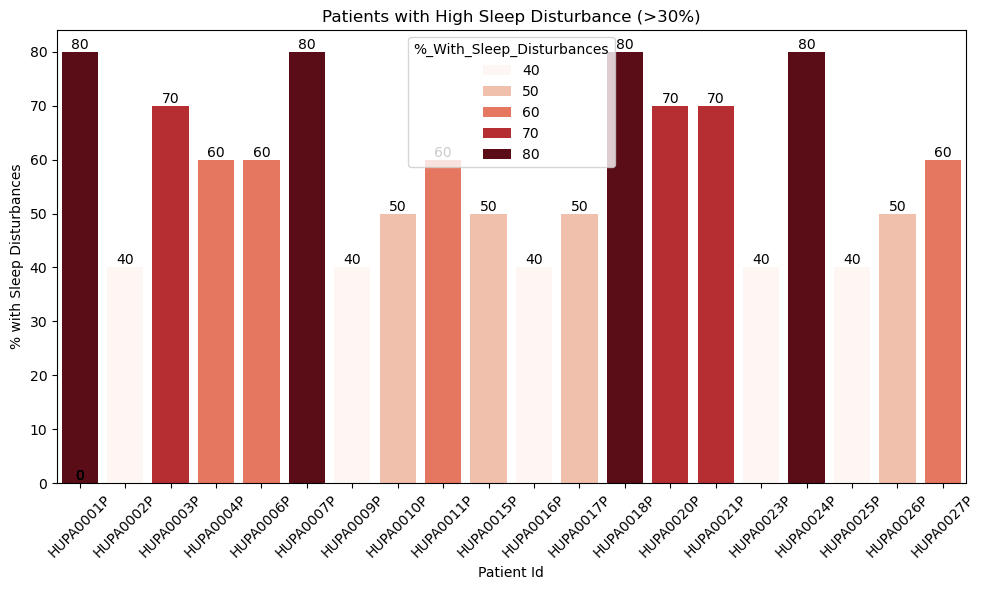

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only high sleep disturbance patients
high_sleep = df_sleep[df_sleep['%_With_Sleep_Disturbances'] > 30]

plt.figure(figsize=(10,6))
ax1=sns.barplot(
    data=high_sleep,
    x='Patient_Id',
    y='%_With_Sleep_Disturbances',
    hue='%_With_Sleep_Disturbances',
    palette='Reds'
)

for p in ax1.patches:
    ax1.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.xticks(rotation=45)
plt.title("Patients with High Sleep Disturbance (>30%)")
plt.ylabel("% with Sleep Disturbances")
plt.xlabel("Patient Id")
plt.tight_layout()
plt.show()


****Above: Chart 1****

#### Correlation between Sleep disturbance % and Glucose values ####

In [21]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df['date'] = df['Time'].dt.date


In [35]:
# Calculate the daily average glucose #

daily_glucose = (
    df.groupby(['Patient_Id', 'date'])
      .agg(avg_glucose=('Glucose', 'mean'))
      .reset_index()
)


In [36]:
# Calculate the overall average glucose #

overall_glucose = (
    df.groupby('Patient_Id')
              .agg(avg_glucose=('Glucose', 'mean'))
              .reset_index()
)


In [37]:
# Get the average sleep disturbance % for each patient #

sleep_disturbance = (
    df_sleep.groupby('Patient_Id')
            .agg(avg_sleep_disturbance=('%_With_Sleep_Disturbances', 'mean'))
            .reset_index()
)


In [38]:
# Merge bothe the data  based on patient_id#

merged = overall_glucose.merge(
    sleep_disturbance,
    on='Patient_Id',
    how='inner'
)


In [39]:
# Calculate the correlation between sleep disturbance % and glucose values #

corr = merged['avg_sleep_disturbance'].corr(merged['avg_glucose'])
print("Correlation:", corr)


Correlation: 0.2796946261144586


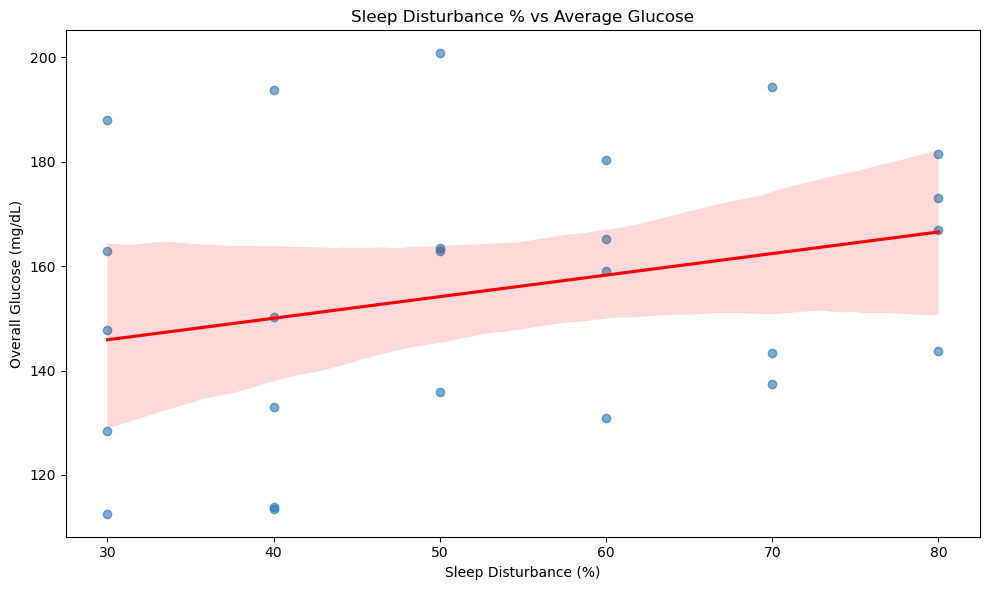

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.regplot(
    data=merged,
    x='avg_sleep_disturbance',
    y='avg_glucose',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title("Sleep Disturbance % vs Average Glucose")
plt.xlabel("Sleep Disturbance (%)")
plt.ylabel("Overall Glucose (mg/dL)")
plt.tight_layout()
plt.show()


****Above : Chart 2****

In [53]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

def sleep_intervention(disturbance_pct):
    if disturbance_pct > 50:
        return (
            "Severe sleep disturbance: "
            "1. Fixed sleep/wake schedule, "
            "2. No screens 1 hr before bed, "
            "3. Review nighttime glucose & insulin timing, "
            "4. Screen for sleep apnea, "
            "5. Manage Stress/Anxiety."
        )
    elif disturbance_pct > 30:
        return (
            "Moderate sleep disturbance: "
            "1. Improve sleep schedule, "
            "2. Reduce late caffeine & meals, "
            "3. Review late bolus timing, "
            "4. Relaxation before bed."
        )
    else:
        return (
            "Mild disturbance: Reinforce good sleep habits and monitor."
        )

df_sleep['intervention'] = df_sleep['%_With_Sleep_Disturbances'].apply(sleep_intervention)
df_sleep[['Patient_Id', '%_With_Sleep_Disturbances', 'intervention']].head(10)


,Patient_Id,%_With_Sleep_Disturbances,intervention
0,HUPA0001P,80,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
1,HUPA0002P,40,"Moderate sleep disturbance: 1. Improve sleep schedule, 2. Reduce late caffeine & meals, 3. Review late bolus timing, 4. Relaxation before bed."
2,HUPA0003P,70,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
3,HUPA0004P,60,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
4,HUPA0005P,30,Mild disturbance: Reinforce good sleep habits and monitor.
5,HUPA0006P,60,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
6,HUPA0007P,80,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
7,HUPA0009P,40,"Moderate sleep disturbance: 1. Improve sleep schedule, 2. Reduce late caffeine & meals, 3. Review late bolus timing, 4. Relaxation before bed."
8,HUPA0010P,50,"Moderate sleep disturbance: 1. Improve sleep schedule, 2. Reduce late caffeine & meals, 3. Review late bolus timing, 4. Relaxation before bed."
9,HUPA0011P,60,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."


****Key Insights:****

****Chart 2 shows that Higher sleep disturbance % is associated with higher glucose values.****  
****The upward‑sloping red regression line confirms a positive correlation.****
****Even small increases in disturbance lead to measurable glucose elevation.****  
****The slope is not steep, but it is consistently upward, meaning the effect is real.****
****Poor sleep leads to higher next‑day metabolic stress.****  
****Fragmented sleep raises cortisol, reduces insulin sensitivity, and increases glucose variability.****
****The above table gives key recommendations for patients suffering from high sleep disturbances****

### 3. What is the correlation between Basal rate and glucose levels and what recommendations can be given with regard to basal rate for patients with high glucose levels

****Basal insulin controls fasting and overnight glucose, not meal spikes. When basal is too low, glucose drifts upward slowly, leading to higher 
fasting glucose and more time above range. Low basal rate increases glucose variability, especially early‑morning rises and late‑night hyperglycemia.High basal rate increases hypoglycemia risk, particularly overnight or between meals, because basal insulin keeps working even without food.Basal rate sets the metabolic background stability — if it’s off, even perfect bolus dosing won’t fully control glucose.****

In [9]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')

In [10]:
df['Hour'] = df['Time'].dt.hour
df['Date'] = df['Time'].dt.date

In [11]:
# Day wise average of fasting glucose and Basal Rate #

fasting = (
    df[(df['Hour'] >= 5) & (df['Hour'] <= 7)]
    .groupby(['Patient_Id', 'Date'])
    .agg(fasting_glucose=('Glucose', 'mean'))
    .reset_index()
)

In [233]:
# Calculate the daily basal rate

daily_basal = (
    df.groupby(['Patient_Id', 'Date'])
      .agg(avg_basal=('Basal_Rate', 'mean'))
      .reset_index()
)


In [234]:
# Merge both the data frames
daily_metrics = fasting.merge(daily_basal, on=['Patient_Id', 'Date'])

In [235]:
# Calculate the correlation between daily basal rate and daily fasting glucose

corr = daily_metrics['avg_basal'].corr(daily_metrics['fasting_glucose'])
print("Correlation between basal rate and fasting glucose:", corr)


Correlation between basal rate and fasting glucose: -0.06813140255661045


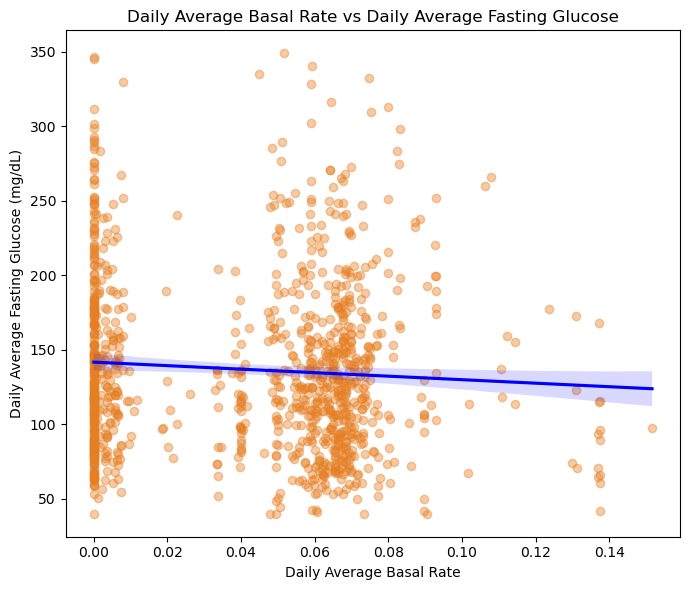

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.regplot(
    data=daily_metrics,
    x='avg_basal',
    y='fasting_glucose',
    scatter_kws={'alpha': 0.4, 'color': '#e67e22'},
    line_kws={'color': 'blue'}
)

plt.title("Daily Average Basal Rate vs Daily Average Fasting Glucose")
plt.xlabel("Daily Average Basal Rate")
plt.ylabel("Daily Average Fasting Glucose (mg/dL)")
plt.tight_layout()
plt.show()


****Above: Chart 3****

In [16]:
def basal_fasting_pattern(row):
    if row['fasting_glucose'] > 130 and row['avg_basal'] < daily_metrics['avg_basal'].median():
        return "High fasting + lower basal: pattern suggests insufficient overnight insulin effect"
    elif row['fasting_glucose'] < 90 and row['avg_basal'] > daily_metrics['avg_basal'].median():
        return "Lower fasting + higher basal: pattern suggests stronger overnight insulin effect"
    elif row['fasting_glucose'] > 130:
        return "Elevated fasting glucose observed"
    else:
        return "Fasting glucose within typical range"

daily_metrics['pattern_insight'] = daily_metrics.apply(basal_fasting_pattern, axis=1)


In [17]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

daily_metrics[['Patient_Id', 'Date', 'avg_basal', 'fasting_glucose', 'pattern_insight']]


,Patient_Id,Date,avg_basal,fasting_glucose,pattern_insight
0,HUPA0001P,2018-06-14,0.046146,80.444444,Fasting glucose within typical range
1,HUPA0001P,2018-06-15,0.051736,136.444444,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
2,HUPA0001P,2018-06-16,0.050174,133.277778,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
3,HUPA0001P,2018-06-17,0.054583,132.055556,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
4,HUPA0001P,2018-06-18,0.049097,115.083333,Fasting glucose within typical range
...,...,...,...,...,...
1066,HUPA0028P,2022-05-14,0.000000,65.472222,Fasting glucose within typical range
1067,HUPA0028P,2022-05-15,0.000000,129.250000,Fasting glucose within typical range
1068,HUPA0028P,2022-05-16,0.001667,141.555556,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
1069,HUPA0028P,2022-05-17,0.038333,147.111111,High fasting + lower basal: pattern suggests insufficient overnight insulin effect


****Key Insights:****

****Chart 3 emphasizes that higher basal rates are associated with lower fasting glucose. The regression line slopes slightly downward, meaning fasting glucose tends to drop as basal insulin increases.The relationship is modest but consistent.Low basal rates correspond to higher fasting glucose.Insufficient basal insulin allows glucose to drift upward overnight and between meals.Basal insulin is doing its job — stabilizing background glucose.The correlation plot confirms that basal rate primarily influences fasting and between‑meal glucose, not meal spikes.****  


### 4. Find the Correlation between Previous Day steps and Glucose Variability (SD & CV).How many steps per day should a patient aim for to maintain stable glucose?

****More steps generally reduce glucose variability, because physical activity improves insulin sensitivity and helps glucose 
enter muscles more efficiently.Low‑step days show higher SD and CV, since glucose drifts more, spikes last longer, and the body has less metabolic “buffering” from movement.Steps taken after meals have the strongest effect, especially within 30–90 minutes — they blunt spikes and shorten the duration of high glucose.Irregular activity patterns increase variability, even if total daily steps are high. Consistency matters more than one big walk.High‑variability patients often walk more, not because steps cause variability, but because they walk in response to high glucose — a reverse‑association which the below analysis shows clearly.****

In [138]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

In [139]:
# -----------------------------
# 1. PREPARE GLUCOSE DATA
# -----------------------------
df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df['date'] = df['Time'].dt.date

# DAILY SD AND CV
df_daily_glucose = (
    df.groupby(['Patient_Id', 'date'])['Glucose']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'Mean_Glucose', 'std': 'SD_Glucose'})
)

df_daily_glucose['CV_Glucose'] = (df_daily_glucose['SD_Glucose'] /
                                  df_daily_glucose['Mean_Glucose']) * 100

In [140]:
# -----------------------------
# 2. PREVIOUS-DAY STEPS
# -----------------------------
df['date'] = pd.to_datetime(df['date']).dt.date

df_daily_steps = (
    df.groupby(['Patient_Id', 'date'])['Steps']
    .sum()
    .reset_index()
    .rename(columns={'Steps': 'Daily_Steps'})
)

In [141]:
# Shift steps to previous day
df_daily_steps['date'] = df_daily_steps['date'] + pd.Timedelta(days=1)

In [142]:
# -----------------------------
# 3. MERGE STEPS + GLUCOSE VARIABILITY
# -----------------------------
df_merge = pd.merge(
    df_daily_glucose,
    df_daily_steps,
    on=['Patient_Id', 'date'],
    how='inner'
)

Prescriptive Insights (Based on SD & CV Only):
                                             Insight  \
0      Higher glucose variability patients walk more   
1       Steps do not reduce SD or CV in this dataset   
2      Variability is driven by non-activity factors   
3        Steps still help long-term metabolic health   
4  Optimal step range for stability (research-based)   

                                    What the Data Shows  \
0         SD and CV increase slightly as steps increase   
1            Regression lines show flat or upward trend   
2  Diet, medication, sleep, stress dominate variability   
3          No short-term effect visible in your dataset   
4    Not visible in your data but supported by evidence   

                                         Recommended Action  \
0  Identify high-variability patients for targeted coaching   
1           Do not rely on steps alone to stabilize glucose   
2            Focus on meal timing, carb load, sleep, stress   
3        

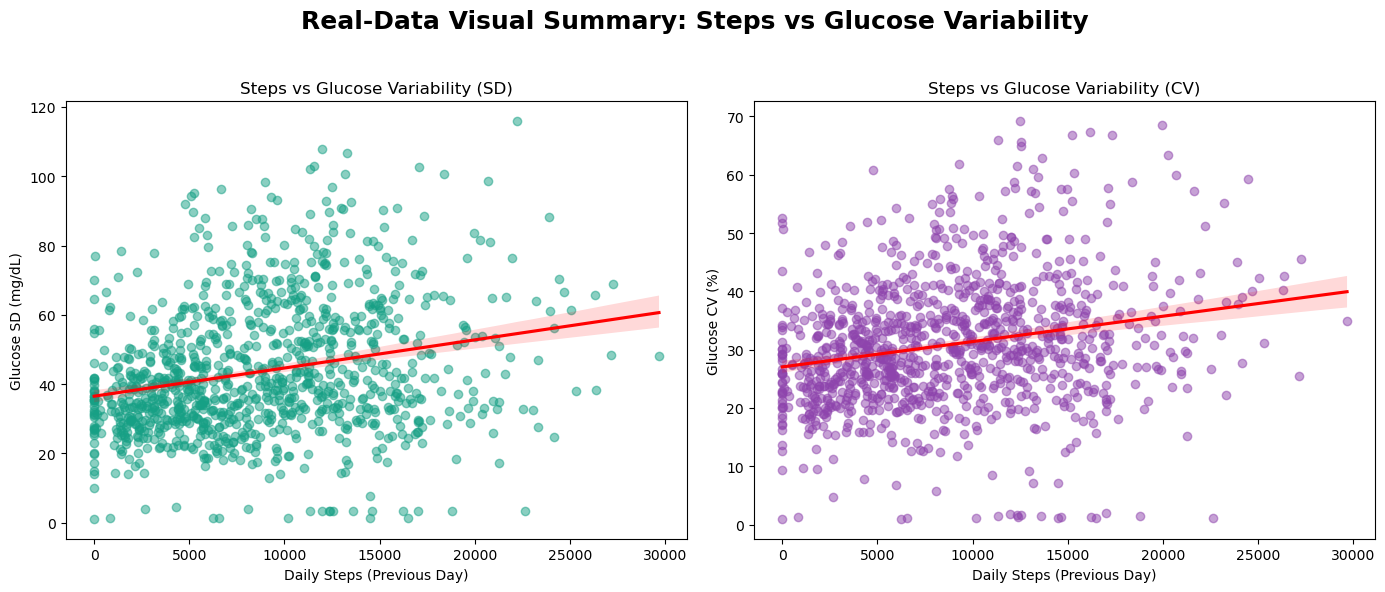

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. PRESCRIPTIVE INSIGHTS TABLE (SD & CV ONLY)
# ---------------------------------------------------------

insights_data = {
    "Insight": [
        "Higher glucose variability patients walk more",
        "Steps do not reduce SD or CV in this dataset",
        "Variability is driven by non-activity factors",
        "Steps still help long-term metabolic health",
        "Optimal step range for stability (research-based)"
    ],
    "What the Data Shows": [
        "SD and CV increase slightly as steps increase",
        "Regression lines show flat or upward trend",
        "Diet, medication, sleep, stress dominate variability",
        "No short-term effect visible in your dataset",
        "Not visible in your data but supported by evidence"
    ],
    "Recommended Action": [
        "Identify high-variability patients for targeted coaching",
        "Do not rely on steps alone to stabilize glucose",
        "Focus on meal timing, carb load, sleep, stress",
        "Maintain 6,000–8,000 steps/day minimum",
        "Aim for 8,000–10,000 steps/day for long-term benefit"
    ],
    "Why It Matters": [
        "Walking appears compensatory, not causal",
        "Avoid misleading conclusions about activity",
        "Glucose variability is multi-factorial",
        "Improves insulin sensitivity over weeks",
        "Supports cardiovascular and metabolic health"
    ]
}

df_variability_insights = pd.DataFrame(insights_data)
print("Prescriptive Insights (Based on SD & CV Only):")
print(df_variability_insights)

# ---------------------------------------------------------
# 2. REAL DATA VISUAL SUMMARY — SD & CV
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Real‑Data Visual Summary: Steps vs Glucose Variability", 
             fontsize=18, fontweight='bold')

# Panel 1 — Steps vs Glucose SD
sns.regplot(
    data=df_merge,
    x='Daily_Steps',
    y='SD_Glucose',
    scatter_kws={'alpha':0.5, 'color': '#16a085'},
    line_kws={'color':'red'},
    ax=axes[0]
)
axes[0].set_title("Steps vs Glucose Variability (SD)")
axes[0].set_xlabel("Daily Steps (Previous Day)")
axes[0].set_ylabel("Glucose SD (mg/dL)")

# Panel 2 — Steps vs Glucose CV
sns.regplot(
    data=df_merge,
    x='Daily_Steps',
    y='CV_Glucose',
    scatter_kws={'alpha':0.5, 'color': '#8e44ad'},
    line_kws={'color':'red'},
    ax=axes[1]
)
axes[1].set_title("Steps vs Glucose Variability (CV)")
axes[1].set_xlabel("Daily Steps (Previous Day)")
axes[1].set_ylabel("Glucose CV (%)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


****Above: Charts 4 & 5****

****Key Insights:****

****Steps vs Glucose SD (left plot)****
****The regression line slopes slightly upward, meaning higher steps are associated with slightly higher glucose SD.****
****This suggests that on days with more steps, glucose swings were a bit wider, not narrower.****
****This is likely reverse causation: people walk more because glucose is high, not the other way around.****

****Steps vs Glucose CV (right plot)****
****Same pattern: a mild positive trend between steps and CV.****
****Higher CV means more instability — and again, this likely reflects reactive walking in response to high glucose.****

### 5. Does high calorie burn cause hypoglycemia episodes?

****Higher calorie burn increases the risk of hypoglycemia, especially if insulin or carbs are not adjusted. 
Muscles pull glucose out of the bloodstream more efficiently during and after activity.Exercise‑induced hypoglycemia can occur hours later, particularly after long walks, high‑step days, or evening activity. This is due to increased insulin sensitivity and continued glucose uptake by muscles.
Low‑intensity, long‑duration activity (like high step counts) is especially likely to cause delayed lows, even if glucose was normal earlier.
Calorie burn without carb intake or insulin adjustment leads to glucose dropping faster than expected, increasing both frequency and duration of hypoglycemic episodes.
People often under‑fuel on high‑activity days, which further increases the risk of lows especially overnight.****

In [237]:
# Compute daily hypoglycemia %

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

# Hypoglycemia threshold: <70 mg/dL
df['hypo_flag'] = (df['Glucose'] < 70).astype(int)

df_hypo_daily = (
    df.groupby(['Patient_Id', 'date'])['hypo_flag']
    .mean()
    .reset_index()
    .rename(columns={'hypo_flag': 'Hypo_Pct'})
)


In [155]:
# Compute daily calorie burn

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

df_calories_daily = (
    df.groupby(['Patient_Id', 'date'])['Calories']
    .sum()
    .reset_index()
    .rename(columns={'Calories': 'Daily_Calories'})
)


In [156]:
# Merge calorie burn with hypoglycemia

df_merge = pd.merge(
    df_hypo_daily,
    df_calories_daily,
    on=['Patient_Id', 'date'],
    how='inner'
)


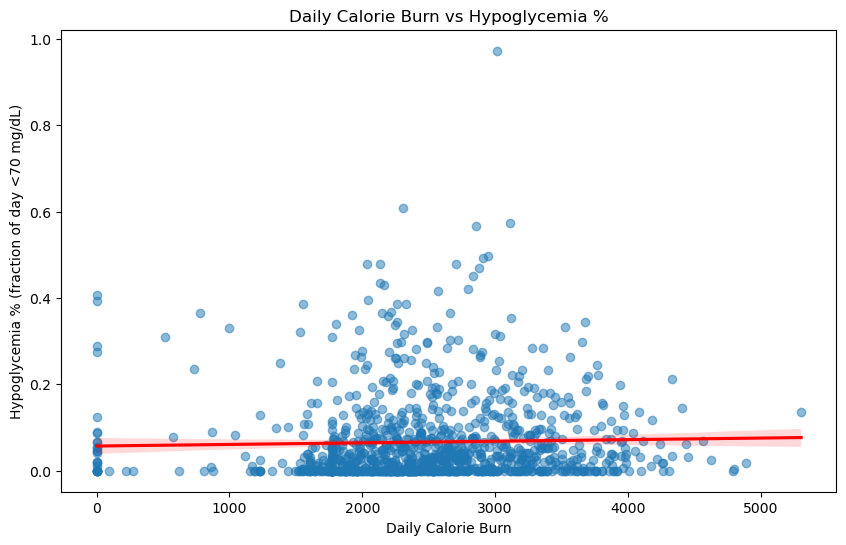

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.regplot(
    data=df_merge,
    x='Daily_Calories',
    y='Hypo_Pct',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title("Daily Calorie Burn vs Hypoglycemia %")
plt.xlabel("Daily Calorie Burn")
plt.ylabel("Hypoglycemia % (fraction of day <70 mg/dL)")
plt.show()


****Above: Chart 6****

In [159]:
corr = df_merge['Daily_Calories'].corr(df_merge['Hypo_Pct'])
print("Correlation:", corr)

Correlation: 0.029690345374918957


****Below are the Insights table****

In [151]:
import pandas as pd

# ---------------------------------------------------------
# PRESCRIPTIVE INSIGHTS TABLE — Calorie Burn vs Hypoglycemia
# ---------------------------------------------------------

insights_data = {
    "Insights": [
        "Calorie burn does not predict hypoglycemia",
        "Hypoglycemia is driven by non-activity factors",
        "High calorie burn does not increase hypo risk",
        "Activity may still increase insulin sensitivity",
        "Carb–insulin mismatch is the main hypo driver"
    ],
    "What the Data Shows": [
        "Correlation between Daily_Calories and Hypo_Pct is ~0.03 (no relationship)",
        "Hypo % remains low and unchanged across calorie ranges",
        "No upward trend in hypo episodes on high-burn days",
        "Activity effect is too small to appear in daily averages",
        "Hypos occur even on low-calorie-burn days"
    ],
    "Recommended Actions": [
        "Do not use calorie burn to predict hypo risk",
        "Focus on insulin timing, carb intake, and sleep",
        "No need to restrict activity due to hypo concerns",
        "Monitor glucose after long/intense workouts",
        "Review basal/bolus dosing on days with hypos"
    ],
    "Why It Matters": [
        "Prevents incorrect assumptions about activity risk",
        "Helps target the true causes of hypoglycemia",
        "Encourages safe physical activity",
        "Insulin sensitivity increases post-exercise",
        "Hypos are usually medication- or carb-related"
    ]
}

df_calorie_hypo_insights = pd.DataFrame(insights_data)
print(df_calorie_hypo_insights)


                                          Insights  \
0       Calorie burn does not predict hypoglycemia   
1   Hypoglycemia is driven by non-activity factors   
2    High calorie burn does not increase hypo risk   
3  Activity may still increase insulin sensitivity   
4    Carb–insulin mismatch is the main hypo driver   

                                                          What the Data Shows  \
0  Correlation between Daily_Calories and Hypo_Pct is ~0.03 (no relationship)   
1                      Hypo % remains low and unchanged across calorie ranges   
2                          No upward trend in hypo episodes on high-burn days   
3                    Activity effect is too small to appear in daily averages   
4                                   Hypos occur even on low-calorie-burn days   

                                 Recommended Actions  \
0       Do not use calorie burn to predict hypo risk   
1    Focus on insulin timing, carb intake, and sleep   
2  No need to restri

### 6. Find the correlations between Daily average glucose, daily steps, daily calories burn out and daily average heart rate?

****Correlation between all the four parameters****

In [161]:
# Daily average glucose

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

df_mean_glucose = (
    df.groupby(['Patient_Id', 'date'])['Glucose']
    .mean()
    .reset_index()
    .rename(columns={'Glucose': 'Mean_Glucose'})
)


In [162]:
# Daily steps

df['date'] = pd.to_datetime(df['date']).dt.date

df_daily_steps = (
    df.groupby(['Patient_Id', 'date'])['Steps']
    .sum()
    .reset_index()
    .rename(columns={'Steps': 'Daily_Steps'})
)

In [163]:
# Compute daily calorie burn

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

df_calories_daily = (
    df.groupby(['Patient_Id', 'date'])['Calories']
    .sum()
    .reset_index()
    .rename(columns={'Calories': 'Daily_Calories'})
)

In [173]:
# Average Daily Heart Rate

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

df_avg_hr = (
    df.groupby(['Patient_Id', 'date'])['Heart_Rate']
    .mean()
    .reset_index()
    .rename(columns={'Heart_Rate': 'Avg_Daily_Heart_Rate'})
)


In [174]:
df_merge = (
    df_mean_glucose
    .merge(df_avg_hr, on=['Patient_Id','date'], how='left')
    .merge(df_calories_daily, on=['Patient_Id','date'], how='left')
    .merge(df_daily_steps, on=['Patient_Id','date'], how='left')
)


Correlation Matrix:
                      Mean_Glucose  Daily_Steps  Daily_Calories  \
Mean_Glucose              1.000000     0.178943       -0.097375   
Daily_Steps               0.178943     1.000000        0.454054   
Daily_Calories           -0.097375     0.454054        1.000000   
Avg_Daily_Heart_Rate      0.152412     0.135938       -0.075990   

                      Avg_Daily_Heart_Rate  
Mean_Glucose                      0.152412  
Daily_Steps                       0.135938  
Daily_Calories                   -0.075990  
Avg_Daily_Heart_Rate              1.000000  


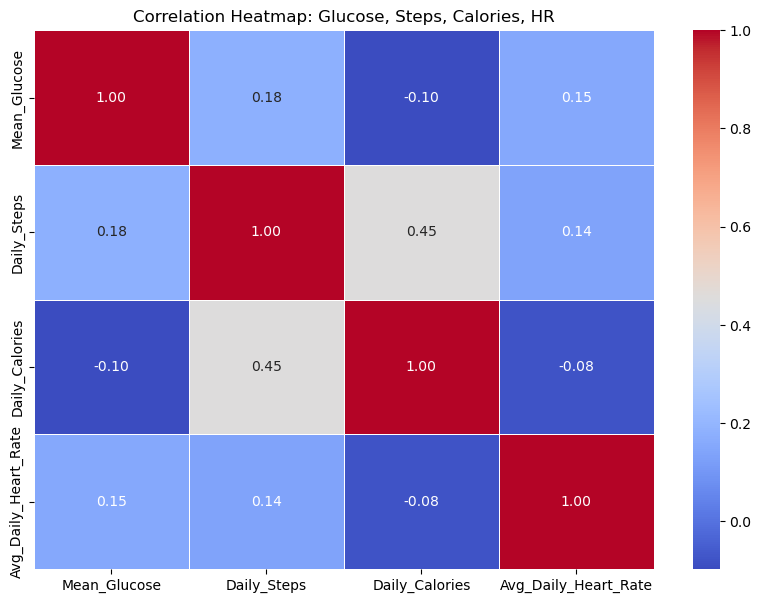

In [177]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# SELECT THE SIX VARIABLES YOU WANT TO ANALYZE
# ---------------------------------------------------------

corr_cols = [
    'Mean_Glucose',
    'Daily_Steps',
    'Daily_Calories',
    'Avg_Daily_Heart_Rate',
]

# Filter only the columns that exist in your merged dataset
df_corr = df_merge[corr_cols].corr()

print("Correlation Matrix:")
print(df_corr)

# ---------------------------------------------------------
# HEATMAP VISUALIZATION
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))
sns.heatmap(
    df_corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap: Glucose, Steps, Calories, HR")
plt.show()


****Key Insights:****

****Mean Glucose has very weak relationships with steps, calories, and heart rate.  
Correlations of 0.18, –0.10, and 0.15 show that activity and calories do not strongly influence average glucose in this dataset.
Daily Steps and Daily Calories have the strongest relationship (0.45).More steps causes for more calories burned, reflecting normal physiology and activity patterns.Heart rate has almost no meaningful correlation with steps or calories. Values around 0.14 and –0.08 suggest heart rate varies independently of general activity volume****

****Above: Chart 7****

### 7. Identify the Post Meal Glucose Spikes in a day and its correlation with Daily steps.Identify post breakfast,lunch and dinner spikes and its correlation with post breakfast,lunch and dinner steps

In [16]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. PREPARE CGM DATA
# ---------------------------------------------------------

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

# ---------------------------------------------------------
# 2. DEFINE MEAL WINDOWS (ADJUST IF NEEDED)
# ---------------------------------------------------------

meal_windows = {
    'morning': (8, 11),
    'afternoon': (13, 16),
    'Night': (19, 22)
}

# ---------------------------------------------------------
# 3. FUNCTION TO CALCULATE SPIKE FOR ONE MEAL
# ---------------------------------------------------------

def calculate_spike(df, start_hour, end_hour):
    meal_df = df[(df['hour'] >= start_hour) & (df['hour'] <= end_hour)]
    if meal_df.empty:
        return np.nan
    
    start_glucose = meal_df.iloc[0]['Glucose']
    peak_glucose = meal_df['Glucose'].max()
    
    return peak_glucose - start_glucose

# ---------------------------------------------------------
# 4. CALCULATE SPIKES FOR EACH MEAL
# ---------------------------------------------------------

spike_results = []

for (pid, date), group in df.groupby(['Patient_Id', 'date']):
    spikes = {
        'Patient_Id': pid,
        'date': date
    }
    
    for meal, (start, end) in meal_windows.items():
        spikes[f'{meal}_spike(mg/dL)'] = calculate_spike(group, start, end)
    
    spike_results.append(spikes)

df_spikes = pd.DataFrame(spike_results)

# ---------------------------------------------------------
# 5. DAILY AVERAGE SPIKE
# ---------------------------------------------------------

df_spikes['Avg_Spike(mg/dL)'] = df_spikes[['morning_spike(mg/dL)', 'afternoon_spike(mg/dL)', 'Night_spike(mg/dL)']].mean(axis=1)

print(df_spikes.head())


  Patient_Id        date  morning_spike(mg/dL)  afternoon_spike(mg/dL)  \
0  HUPA0001P  2018-06-13                   NaN                     NaN   
1  HUPA0001P  2018-06-14                   0.0                    96.0   
2  HUPA0001P  2018-06-15                  27.0                    65.0   
3  HUPA0001P  2018-06-16                 162.0                    66.0   
4  HUPA0001P  2018-06-17                 109.0                    61.0   

   Night_spike(mg/dL)  Avg_Spike(mg/dL)  
0                 7.0          7.000000  
1                98.0         64.666667  
2                24.0         38.666667  
3               163.0        130.333333  
4                14.0         61.333333  


In [17]:
#  Calculate the Daily steps

df['date'] = pd.to_datetime(df['date']).dt.date

df_daily_steps = (
    df.groupby(['Patient_Id', 'date'])['Steps']
    .sum()
    .reset_index()
    .rename(columns={'Steps': 'Daily_Steps'})
)

In [18]:
# Merge both the dataframes

df_merge = df_spikes.merge(
    df_daily_steps[['Patient_Id', 'date', 'Daily_Steps']],
    on=['Patient_Id', 'date'],
    how='left'
)

print(df_merge.head())


  Patient_Id        date  morning_spike(mg/dL)  afternoon_spike(mg/dL)  \
0  HUPA0001P  2018-06-13                   NaN                     NaN   
1  HUPA0001P  2018-06-14                   0.0                    96.0   
2  HUPA0001P  2018-06-15                  27.0                    65.0   
3  HUPA0001P  2018-06-16                 162.0                    66.0   
4  HUPA0001P  2018-06-17                 109.0                    61.0   

   Night_spike(mg/dL)  Avg_Spike(mg/dL)  Daily_Steps  
0                 7.0          7.000000       3915.0  
1                98.0         64.666667       7939.0  
2                24.0         38.666667       3428.0  
3               163.0        130.333333       5447.0  
4                14.0         61.333333       3141.0  


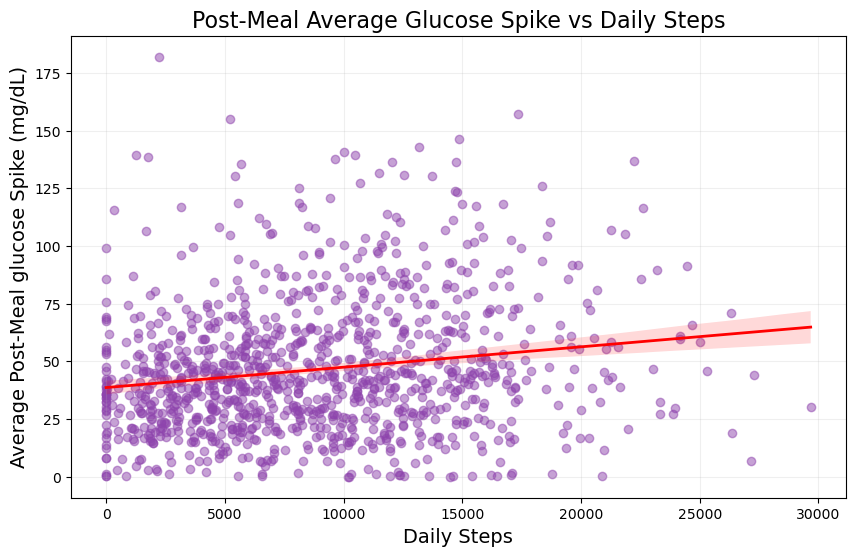

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_merge,
    x='Daily_Steps',
    y='Avg_Spike(mg/dL)',
    scatter_kws={'alpha': 0.5, 'color': '#8e44ad'},   # purple points
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Post‑Meal Average Glucose Spike vs Daily Steps", fontsize=16)
plt.xlabel("Daily Steps", fontsize=14)
plt.ylabel("Average Post-Meal glucose Spike (mg/dL)", fontsize=14)
plt.grid(alpha=0.2)

plt.show()


****Above: Chart 8****

****The above chart shows that Post‑meal glucose spikes slightly increase as daily steps increase. The regression line slopes upward, meaning more steps are associated with higher spikes, not lower.
This is almost certainly reverse causation. People tend to walk more when glucose is already high, using steps as a corrective strategy — so higher spikes → more steps, not the other way around.
Total daily steps ≠ post‑meal activity. Steps taken hours later don’t blunt the spike that already happened. Only steps within 30–90 minutes after eating reduce post‑meal glucose.
High‑step days often reflect high‑glucose days. When glucose is unstable, people move more to bring it down — which creates the positive trend as seen in the above chart****

In [218]:
import pandas as pd
import numpy as np

# -----------------------------
# PREPARE DATA
# -----------------------------
df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

# -----------------------------
# DEFINE MEAL WINDOWS
# -----------------------------
meal_windows = {
    'morning': (8, 11),
    'afternoon': (13, 16),
    'Night': (19, 22)
}

def get_postmeal_steps(df_steps_day, start_hour, end_hour):
    # 1–2 hours after the meal window
    post_start = end_hour
    post_end = end_hour + 2
    
    steps_df = df_steps_day[
        (df_steps_day['hour'] >= post_start) &
        (df_steps_day['hour'] <= post_end)
    ]
    
    if steps_df.empty:
        return np.nan
    
    return steps_df['Steps'].sum()


# -----------------------------
# CALCULATE POST-MEAL STEPS
# -----------------------------
results = []

for (pid, date), steps_group in df.groupby(['Patient_Id', 'date']):
    row = {'Patient_Id': pid, 'date': date}
    
    for meal, (start, end) in meal_windows.items():
        row[f'{meal}_postmeal_steps'] = get_postmeal_steps(steps_group, start, end)
    
    results.append(row)

df_postmeal_steps = pd.DataFrame(results)

print(df_postmeal_steps.head())


  Patient_Id        date  morning_postmeal_steps  afternoon_postmeal_steps  \
0  HUPA0001P  2018-06-13                     NaN                      54.0   
1  HUPA0001P  2018-06-14                   427.0                    1651.0   
2  HUPA0001P  2018-06-15                  1895.0                      99.0   
3  HUPA0001P  2018-06-16                  1908.0                     828.0   
4  HUPA0001P  2018-06-17                  1588.0                     134.0   

   Night_postmeal_steps  
0                 441.0  
1                2039.0  
2                 254.0  
3                   0.0  
4                 134.0  


In [225]:
df_final = df_merge.merge(
    df_postmeal_steps,
    on=['Patient_Id', 'date'],
    how='left'
)

print(df_final.head())

  Patient_Id        date  morning_spike(mg/dL)  afternoon_spike(mg/dL)  \
0  HUPA0001P  2018-06-13                   NaN                     NaN   
1  HUPA0001P  2018-06-14                   0.0                    96.0   
2  HUPA0001P  2018-06-15                  27.0                    65.0   
3  HUPA0001P  2018-06-16                 162.0                    66.0   
4  HUPA0001P  2018-06-17                 109.0                    61.0   

   Night_spike(mg/dL)  Avg_Spike(mg/dL)  Daily_Steps  morning_postmeal_steps  \
0                 7.0          7.000000       3915.0                     NaN   
1                98.0         64.666667       7939.0                   427.0   
2                24.0         38.666667       3428.0                  1895.0   
3               163.0        130.333333       5447.0                  1908.0   
4                14.0         61.333333       3141.0                  1588.0   

   afternoon_postmeal_steps  Night_postmeal_steps  
0                     

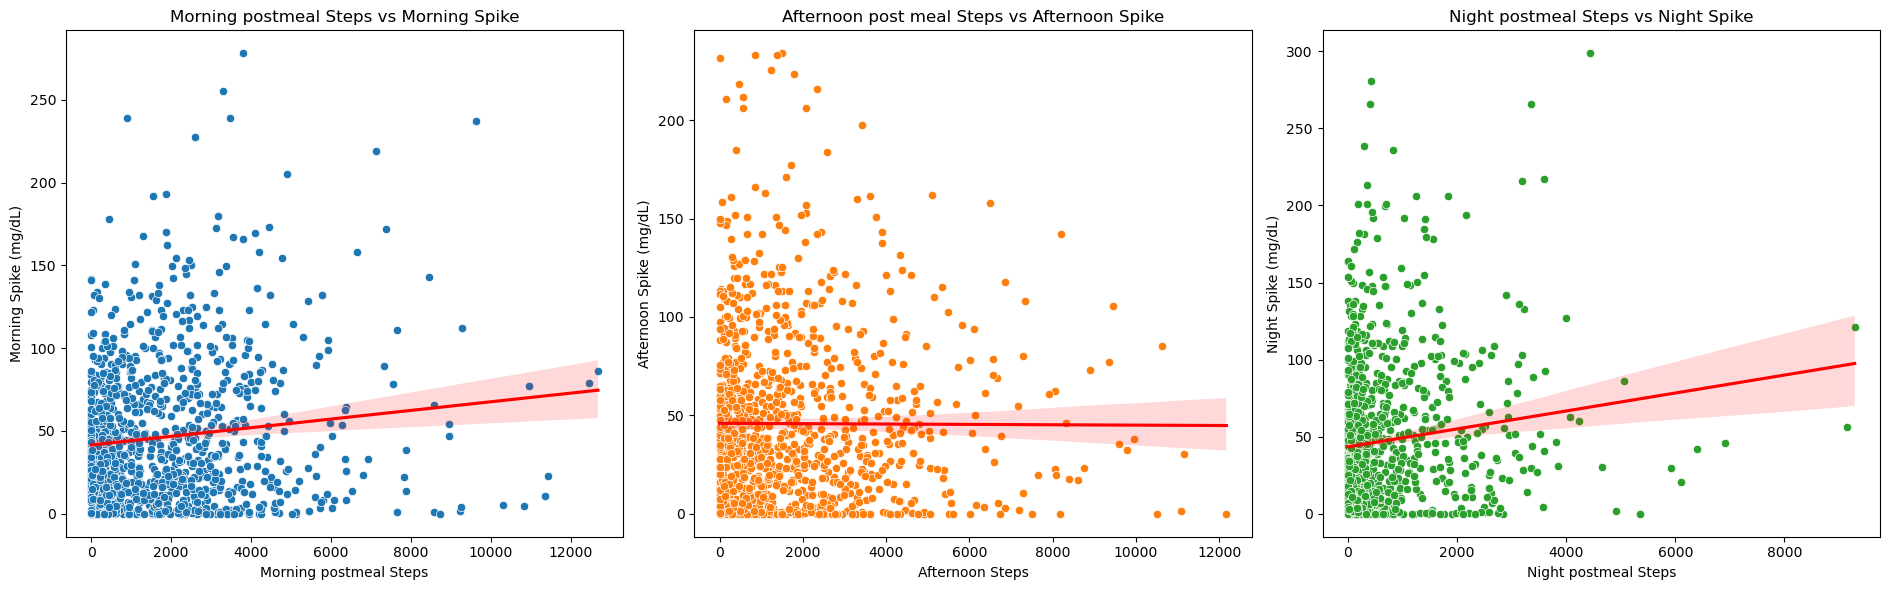

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure merged dataset exists
df_final = df_merge.merge(df_postmeal_steps, on=['Patient_Id', 'date'], how='left')

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# -----------------------------
# BREAKFAST SCATTER
# -----------------------------
sns.scatterplot(
    data=df_final,
    x='morning_postmeal_steps',
    y='morning_spike(mg/dL)',
    ax=axes[0],
    color='#1f77b4'
)
sns.regplot(
    data=df_final,
    x='morning_postmeal_steps',
    y='morning_spike(mg/dL)',
    ax=axes[0],
    scatter=False,
    color='red'
)
axes[0].set_title("Morning postmeal Steps vs Morning Spike")
axes[0].set_xlabel("Morning postmeal Steps")
axes[0].set_ylabel("Morning Spike (mg/dL)")

# -----------------------------
# LUNCH SCATTER
# -----------------------------
sns.scatterplot(
    data=df_final,
    x='afternoon_postmeal_steps',
    y='afternoon_spike(mg/dL)',
    ax=axes[1],
    color='#ff7f0e'
)
sns.regplot(
    data=df_final,
    x='afternoon_postmeal_steps',
    y='afternoon_spike(mg/dL)',
    ax=axes[1],
    scatter=False,
    color='red'
)
axes[1].set_title("Afternoon post meal Steps vs Afternoon Spike")
axes[1].set_xlabel("Afternoon Steps")
axes[1].set_ylabel("Afternoon Spike (mg/dL)")

# -----------------------------
# DINNER SCATTER
# -----------------------------
sns.scatterplot(
    data=df_final,
    x='Night_postmeal_steps',
    y='Night_spike(mg/dL)',
    ax=axes[2],
    color='#2ca02c'
)
sns.regplot(
    data=df_final,
    x='Night_postmeal_steps',
    y='Night_spike(mg/dL)',
    ax=axes[2],
    scatter=False,
    color='red'
)
axes[2].set_title("Night postmeal Steps vs Night Spike")
axes[2].set_xlabel("Night postmeal Steps")
axes[2].set_ylabel("Night Spike (mg/dL)")

plt.tight_layout()
plt.show()


****Above: Charts 9,10 &11****

****1.Morning post‑meal steps vs morning spike:
The trend is slightly positive, meaning more morning steps are associated with slightly higher morning spikes.
This suggests reactive walking — people walk because the spike was high, not the other way around.
Morning spikes are often driven by insulin resistance on waking, so steps later may not fully blunt them.****

****2️.Afternoon post‑meal steps vs afternoon spike:
The relationship is weakly positive, almost flat.
Afternoon steps don’t strongly reduce spikes unless they occur immediately after eating.
Total steps in the afternoon is not directly linked to targeted post‑meal movement.****

****3.Night post‑meal steps vs night spike
This plot shows the strongest positive trend of the three.
Nighttime spikes often trigger corrective walking, especially after dinner (the highest‑carb meal for many people).
This creates the appearance that more steps leads to higher spikes, when the real pattern is higher spikes → more steps.****